# ITO5201 – Assessment 1: Section 3
## Ridge Regression
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

---
## Question 6 – Ridge Regression
### Q6.I – Derivation: Gradient of the Regularised Error Function

**Regularised error function:**

$$E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\sum_{j=0}^{M-1}w^{2}_j$$

$$= \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\mathbf{w}^{\top}\mathbf{w}$$

**Gradient derivation:**

We differentiate $E(\mathbf{w})$ with respect to a single weight $w_j$ using the chain rule:

$$\frac{\partial E}{\partial w_j} = \frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] + \frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right]$$

For the **error term**, applying the chain rule:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

For the **regularisation term**, only the $k=j$ term survives:

$$\frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right] = \lambda w_j$$

Combining both terms:

$$\frac{\partial E}{\partial w_j} = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n) + \lambda w_j$$

Collecting all partial derivatives into the gradient vector $\nabla_{\mathbf{w}} E(\mathbf{w})$ and writing in matrix notation, where $\Phi \in \mathbb{R}^{N \times M}$ is the design matrix whose $n$-th row is $\Phi(\mathbf{x}_n)^\top$ and $\mathbf{t} \in \mathbb{R}^N$ is the target vector:

$$\boxed{\nabla_{\mathbf{w}} E(\mathbf{w}) = -\Phi^{\top}(\mathbf{t} - \Phi\mathbf{w}) + \lambda\mathbf{w} = (\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t}}$$

---

*Derivation context: the unregularised least-squares gradient and its normal-equations solution are developed in Activity 2.1 (Modules/2/Activities/Activity.2.1_solutions.ipynb, Task B and the Gradient Descent section); the ridge penalty term extends that error function as introduced in Activity 2.2 (Regularisation).*

### Q6.I – Derivation: Closed-Form Solution

Setting $\nabla_{\mathbf{w}} E(\mathbf{w}) = \mathbf{0}$ and solving for $\mathbf{w}$:

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t} = \mathbf{0}$$

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} = \Phi^{\top}\mathbf{t}$$

The matrix $(\Phi^{\top}\Phi + \lambda\mathbf{I})$ is positive definite for any $\lambda > 0$ (since $\lambda\mathbf{I}$ adds a positive diagonal shift), so it is always invertible. Multiplying both sides on the left by its inverse:

$$\boxed{\mathbf{w}^* = (\Phi^{\top}\Phi + \lambda\mathbf{I})^{-1}\Phi^{\top}\mathbf{t}}$$

### Q6.II – Implement `RidgeRegressor`

In [2]:
# MODEL: Ridge Regression Implementation

class RidgeRegressor(BaseEstimator):

    """
    Class implementing Ridge Regression using the closed-form solution.

    Source: the closed-form solve via np.linalg.solve follows Activity 2.1
    (Modules/2/Activities/Activity.2.1_solutions.ipynb, Task B: Normal Equations),
    extended here with the lambda*I ridge penalty; regularisation concepts are
    covered in Activity 2.2 (Regularisation).

    __init__(self, lambda_=1.0): Initializes the RidgeRegressor with a regularization parameter lambda_.
    fit(self, X, y): Fits the Ridge Regression model to the training data (X, y) using the closed-form solution.
    - X: Training data features (numpy array of shape [n_samples, n_features]).
    - y: Target values (numpy array of shape [n_samples]).
    predict(self, X): Predicts the target values for the input data X using the fitted model.
    - X: Input data features (numpy array of shape [n_samples, n_features]).

    Numpy functions used:
    - np.eye: Creates an identity matrix of given size.
    ref: https://numpy.org/doc/stable/reference/generated/numpy.eye.html
    - np.linalg.solve: Solves a linear matrix equation or system of linear scalar equations.
    ref: https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html

    Ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
    

    """

    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_

    def fit(self, X, y) -> 'RidgeRegressor':
        n_features = X.shape[1] # Get the number of features in the input data
        I_matrix = np.eye(n_features)
        # Compute the closed-form solution for Ridge Regression coefficients
        # X.T @ X: Computes the dot product of the transpose of X and X.
        # self.lambda_ * I_matrix: Adds the regularization term to the diagonal of the matrix.
        # X.T @ y: Computes the dot product of the transpose of X and the target values y.
        # LATEX: \hat{\beta} = (X^TX + \lambda I)^{-1}X^Ty
        self.coef_ = np.linalg.solve(X.T @ X + self.lambda_ * I_matrix, X.T @ y)
        return self

    def predict(self, X) -> np.ndarray:
        return X @ self.coef_

### Q6.III – Study Effect of λ on Training and Test Error
#### Synthetic Data Generator

In [3]:
# DATA GENERATION: Synthetic Data Generation

def generate_data(n, rng=None) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate synthetic data:
      X ~ Uniform(-0.3, 0.3)
      Y = sin(5*pi*x) / (1 + 2*x) + eps, eps ~ N(0, 0.1) — variance 0.1, i.e. std = sqrt(0.1)

    Source: Adapted from Activity 2.3 (Modules/2/Activities/Activity.2.3_solutions.ipynb) —
    the target function f(x) = sin(5*pi*x)/(1+2*x) and the additive-noise sampling
    scheme follow make_additive_noise_data from that activity.
    
    Parameters:
    - n: Number of samples to generate.
    - rng: Optional random number generator for reproducibility. If None, a new generator is created.

    Returns:
    - X: Generated input features (numpy array of shape [n_samples, 1]).
    - y: Generated target values (numpy array of shape [n_samples]).
      
    """

    if rng is None:
        rng = np.random.default_rng()
    
    X = rng.uniform(-0.3, 0.3, size=(n, 1)) # Generate n samples from a uniform distribution in the range [-0.3, 0.3]
    eps = rng.normal(0, 0.1 ** 0.5, size=n)  # std = sqrt(0.1): N(0, 0.1) has variance 0.1, matching Activity 2.3 (noise=0.1**0.5) # Generate n samples of additive noise from a normal distribution with mean 0 and standard deviation 0.1
    y = np.sin(5 * np.pi * X[:, 0]) / (1 + 2 * X[:, 0]) + eps # Compute the target values using the specified function and add the noise
    return X, y # Return the generated input features and target values as a tuple


In [4]:
# EXPERIMENT: Ridge Regression Pipeline
# Pipeline: PolynomialFeatures(degree=5) + RidgeRegressor

"""
Source: Adapted from Activity 2.3 (Modules/2/Activities/Activity.2.3_solutions.ipynb),
section "Polynomial Feature Expansion, Transformations, and Pipelines" (Tasks C-E),
which combines PolynomialFeatures with a linear model in an sklearn Pipeline.
This function creates a pipeline for Ridge Regression with polynomial feature expansion.
Parameters:
- lambda_: Regularization parameter for Ridge Regression.
Returns:
- A scikit-learn Pipeline object that first transforms the input features using PolynomialFeatures of degree 5, 
and then applies Ridge Regression with the specified lambda_.

What is PolynomialFeatures?
PolynomialFeatures is a preprocessing technique that generates polynomial and interaction features from the original features.
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
"""

def make_pipeline(lambda_):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=5)),
        ('ridge', RidgeRegressor(lambda_=lambda_))
    ])

#### Experiment: 10 repetitions × 101 λ values

In [5]:
# EXECUTION: Run the Ridge Regression experiment with multiple repetitions and compute train/test MSE

"""
This cell runs the Ridge Regression experiment by generating synthetic data,
 fitting the model for different values of lambda, 
 and computing the Mean Squared Error (MSE) for both training and testing datasets. 
 The results are stored in arrays for further analysis or plotting.

 Source: the experiment design follows Activity 2.2
 (Modules/2/Activities/Activity.2.2_solutions.ipynb, "Effect of Regularisation
 Parameter Value") — an exponentially spaced grid of lambda values
 (np.geomspace here, numpy.logspace there) with train and test error curves;
 averaging over repeated data draws follows the reps pattern of Activity 2.3.

 Numpy functions used:
- np.random.default_rng: Creates a new random number generator.
ref: https://numpy.org/doc/stable/reference/random/generator.html
- np.geomspace: Generates numbers spaced evenly on a log scale (geometric progression).
ref: https://numpy.org/doc/stable/reference/generated/numpy.geomspace.html
- np.zeros: Creates an array filled with zeros.
ref: https://numpy.org/doc/stable/reference/generated/numpy.zeros.html
- np.mean: Computes the arithmetic mean along the specified axis.
ref: https://numpy.org/doc/stable/reference/generated/numpy.mean.html
"""

rng = np.random.default_rng(0)
lambdas = np.geomspace(1e-10, 0.1, 101, endpoint=True)
n_reps = 10
n_train = 20

x_test, y_test = generate_data(1000, rng)

train_mse_all = np.zeros((n_reps, len(lambdas)))
test_mse_all  = np.zeros((n_reps, len(lambdas)))

for rep in range(n_reps):
    x_train, y_train = generate_data(n_train, rng)
    for i, lambda_ in enumerate(lambdas):
        model = make_pipeline(lambda_)
        model.fit(x_train, y_train)
        train_mse_all[rep, i] = np.mean((model.predict(x_train) - y_train) ** 2)
        test_mse_all[rep, i]  = np.mean((model.predict(x_test)  - y_test)  ** 2)


#### Plot: log-MSE vs log-λ

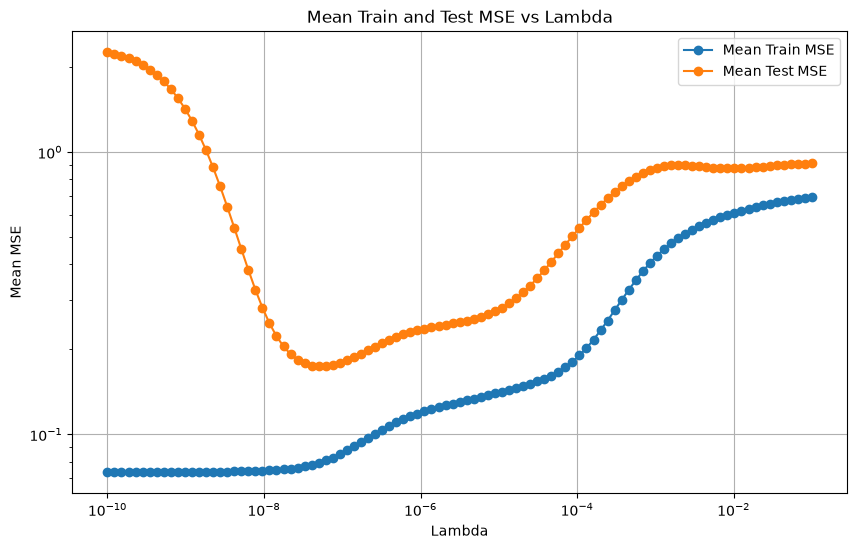

In [6]:
# PLOTTING: Plot Mean Train and Test MSE vs Lambda

"""
This function plots the mean train and test Mean Squared Error (MSE) against different values of the regularization parameter lambda.
Parameters:
- lambdas: A list or array of lambda values used for Ridge Regression.
- train_mse_list: A 2D array where each row corresponds to the train MSE for a specific repetition and each column corresponds to a lambda value.
- test_mse_list: A 2D array where each row corresponds to the test MSE for a specific repetition and each column corresponds to a lambda value.

Numpy functions used:
- np.mean: Computes the mean of array elements along a specified axis.
Ref: https://numpy.org/doc/stable/reference/generated/numpy.mean.html

"""

def plot_mse_vs_lambda(lambdas, train_mse_list, test_mse_list):
    mean_train_mse = np.mean(train_mse_list, axis=0)
    mean_test_mse = np.mean(test_mse_list, axis=0)

    plt.figure(figsize=(10, 6))
    plt.loglog(lambdas, mean_train_mse, label='Mean Train MSE', marker='o')
    plt.loglog(lambdas, mean_test_mse, label='Mean Test MSE', marker='o')
    plt.xlabel('Lambda')
    plt.ylabel('Mean MSE')
    plt.title('Mean Train and Test MSE vs Lambda')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse_vs_lambda(lambdas, train_mse_all, test_mse_all)


#### Discussion: λ, Model Complexity, Underfitting and Overfitting

**Effect of λ on model complexity**

The regularisation parameter λ controls how strongly the weights $\mathbf{w}$ are penalised toward zero. A larger λ reduces the effective flexibility of the model — even though the polynomial feature map is always degree 5, the model's capacity to fit complex curves is determined by the magnitude of its weights, which λ directly suppresses.

**Observed behaviour**

The log–log plot shows the classic U-shaped test error curve with three distinct regimes:

- **Overfitting (λ ≲ 10⁻⁸):** Train MSE sits flat at ≈ 0.074 — *below* the irreducible noise variance of $\operatorname{var}(\epsilon) = 0.1$, the signature of a model fitting the noise rather than the signal. Test MSE is enormous (≈ 2.26 at λ = 10⁻¹⁰, more than 12× the optimum): with only $N = 20$ training points, the near-unregularised degree-5 fit is dominated by variance, and small changes in the training sample produce wildly different coefficient vectors.

- **Optimal region (λ ≈ 10⁻⁸–10⁻⁷):** Test MSE reaches its minimum of ≈ 0.17 at λ ≈ 5×10⁻⁸, approaching the irreducible error floor of 0.1. The penalty is just strong enough to suppress the noise-driven coefficient variance without yet introducing noticeable bias (train MSE is still ≈ 0.08).

- **Underfitting (λ ≳ 10⁻³):** Both curves rise and converge — train goes 0.43 → 0.69 and test 0.88 → 0.91 as λ goes 10⁻³ → 10⁻¹ — because the penalty shrinks all weights toward zero and the model degenerates toward predicting a near-constant value. The error here is systematic (bias), not variance: the train–test gap largely closes while both errors are high.

**Summary**

| λ range | Train MSE | Test MSE | Regime |
|---|---|---|---|
| 10⁻¹⁰ – 10⁻⁸ | ≈ 0.074 (below var(ε) = 0.1) | 2.26 falling to ≈ 0.2 | Overfitting (high variance) |
| ≈ 5×10⁻⁸ | ≈ 0.08 | **≈ 0.17** (minimum) | Optimal bias–variance trade-off |
| 10⁻³ – 10⁻¹ | 0.43 → 0.69 | 0.88 → 0.91 | Underfitting (high bias) |

λ therefore acts as a direct dial on effective model complexity: too little regularisation lets the six polynomial coefficients chase the noise in the 20 training points (low bias, high variance), while too much collapses the model toward the global mean (high bias, low variance). The optimum sits where the test error touches down near the irreducible noise floor.

---
## Appendix – Detailed Chain Rule Explanation for the Gradient Derivation

### Why the chain rule is needed

The error term contains a **composition of functions** — a square applied to a linear expression in $\mathbf{w}$. The chain rule tells us how to differentiate a composition $f(g(x))$:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

### Step-by-step application

We want to differentiate the error term with respect to a single weight $w_j$:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right]$$

**Step 1 — Introduce a substitution to make the composition explicit.**

Let $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$. The expression becomes:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N} u_n^{2}\right]$$

This is now clearly a composition: the outer function is $\frac{1}{2}u_n^2$ and the inner function is $u_n(w_j)$.

**Step 2 — Differentiate the outer function** $\frac{1}{2}u_n^2$ with respect to $u_n$:

$$\frac{d}{du_n}\left[\frac{1}{2}u_n^2\right] = \frac{1}{2} \cdot 2u_n = u_n$$

The $\frac{1}{2}$ and the $2$ from the power rule cancel — this is exactly why the $\frac{1}{2}$ was included in the error function definition in the first place.

**Step 3 — Differentiate the inner function** $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$ with respect to $w_j$.

Expanding the dot product:

$$u_n = t_n - \sum_{k=0}^{M-1} w_k \, \phi_k(\mathbf{x}_n)$$

$t_n$ is a constant with respect to $\mathbf{w}$, so:

$$\frac{\partial u_n}{\partial w_j} = -\frac{\partial}{\partial w_j}\sum_{k=0}^{M-1} w_k\,\phi_k(\mathbf{x}_n) = -\phi_j(\mathbf{x}_n)$$

Only the $k = j$ term survives differentiation; all other terms vanish because $\frac{\partial w_k}{\partial w_j} = 0$ for $k \neq j$.

**Step 4 — Multiply outer × inner (chain rule):**

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}u_n^2\right] = u_n \cdot \frac{\partial u_n}{\partial w_j} = (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)) \cdot (-\phi_j(\mathbf{x}_n))$$

Summing over all $N$ data points:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

### Summary of what happened to the $\frac{1}{2}$

The $\frac{1}{2}$ was not dropped — it was **cancelled** by the factor of $2$ produced by the power rule when differentiating $u_n^2$. This is the standard reason for including $\frac{1}{2}$ in the definition of the error function: it keeps the gradient clean.